## Ungraded Lab: MNIST Autoencoder

You will now work on an autoencoder that works on the [MNIST dataset](https://www.tensorflow.org/datasets/catalog/mnist). This will encode the inputs to lower resolution images. The decoder should then be able to generate the original input from this compressed representation.

In [22]:
!pip install tensorflow_datasets

## Imports

In [23]:
try:
  # %tensorflow_version only exists in Colab.
  %tensorflow_version 2.x
except Exception:
  pass
  
import tensorflow as tf
import tensorflow_datasets as tfds

import numpy as np
import matplotlib.pyplot as plt

## Prepare the Dataset

You will load the MNIST data from TFDS into train and test sets. Let's first define a preprocessing function for normalizing and flattening the images. Since we'll be training an autoencoder, this will return `image, image` because the input will also be the target or label while training.

##### map() function is used to apply a transformation to every element in the dataset.


In [24]:
def map_image(image, label):
  '''Normalizes and flattens the image. Returns image as input and label.'''
  image = tf.cast(image, dtype=tf.float32)
  image = image / 255.0
  image = tf.reshape(image, shape=(784,))

  return image, image

In [28]:
# Load the train and test sets from TFDS

BATCH_SIZE = 128
SHUFFLE_BUFFER_SIZE = 1024

train_dataset = tfds.load('mnist', as_supervised=True, split="train")
train_dataset = train_dataset.map(map_image)
train_dataset = train_dataset.shuffle(SHUFFLE_BUFFER_SIZE).batch(BATCH_SIZE).repeat()

test_dataset = tfds.load('mnist', as_supervised=True, split="test")
test_dataset = test_dataset.map(map_image)
test_dataset = test_dataset.batch(BATCH_SIZE).repeat()

## Build the Model

You will now build a simple autoencoder to ingest the data. Like before, the encoder will compress the input and reconstructs it in the decoder output.

[![auto.png](https://i.postimg.cc/c4nvrC5h/auto.png)](https://postimg.cc/kB7JHJCR)

In [30]:

# set the input shape
#inputs =  tf.keras.layers.Input(shape=(784,))

# get the encoder and decoder output
#encoder_output, decoder_output = simple_autoencoder(inputs)

# setup the encoder because you will visualize its output later
#encoder_model = tf.keras.Model(inputs=inputs, outputs=encoder_output)

# setup the autoencoder
#autoencoder_model = tf.keras.Model(inputs=inputs, outputs=decoder_output)

#above code is  already given below is my code 
import tensorflow as tf

# 1. Define the function (This was missing!)
def simple_autoencoder(inputs):
    # Encoder: Dense 32 with ReLU activation
    encoder_output = tf.keras.layers.Dense(32, activation='relu')(inputs)
    
    # Decoder: Dense 784 with Sigmoid activation
    decoder_output = tf.keras.layers.Dense(784, activation='sigmoid')(encoder_output)
    
    return encoder_output, decoder_output

# 2. Set the input shape (Matching MNIST 28x28 = 784)
inputs = tf.keras.layers.Input(shape=(784,))

# 3. Get the encoder and decoder outputs from our function
encoder_output, decoder_output = simple_autoencoder(inputs)

# 4. Setup the encoder model for visualization
encoder_model = tf.keras.Model(inputs=inputs, outputs=encoder_output)

# 5. Setup the full autoencoder model for training
autoencoder_model = tf.keras.Model(inputs=inputs, outputs=decoder_output)

# Summary to verify the architecture
autoencoder_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │          25,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 784)                 │          25,872 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,992 (199.19 KB)

 Trainable params: 50,992 (199.19 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
autoencoder_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │          25,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 784)                 │          25,872 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,992 (199.19 KB)

 Trainable params: 50,992 (199.19 KB)

 Non-trainable params: 0 (0.00 B)

## Compile the Model

You will setup the model for training. You can use binary crossentropy to measure the loss between pixel values that range from 0 (black) to 1 (white).

In [32]:
autoencoder_model.compile(
    optimizer=tf.keras.optimizers.Adam(), 
    loss='binary_crossentropy',metrics=['accuracy'])

## Train the Model

In [33]:
train_steps = 60000 // BATCH_SIZE
simple_auto_history = autoencoder_model.fit(train_dataset, steps_per_epoch=train_steps, epochs=50)

Epoch 1/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.0110 - loss: 0.2293
Epoch 2/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.0106 - loss: 0.1418
Epoch 3/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.0111 - loss: 0.1196
Epoch 4/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.0127 - loss: 0.1076
Epoch 5/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.0127 - loss: 0.1009
Epoch 6/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.0128 - loss: 0.0974
Epoch 7/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.0123 - loss: 0.0957
Epoch 8/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.0118 - loss: 0.0950
Epoch 9/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.0113 - loss: 0.0945
Epoch 10/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.0111 - loss: 0.0942
Epoch 11/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.0112 - loss: 0.0940
Epoch 12/50
468/468 ━━━━━━━━━━━━━━━━━━━━

## Display sample results

You can now visualize the results. The utility functions below will help in plotting the encoded and decoded values.

In [37]:
def display_one_row(disp_images, offset, shape=(28, 28)):
  '''Display sample outputs in one row.'''
  for idx, test_image in enumerate(disp_images):
    plt.subplot(3, 10, offset + idx + 1)
    plt.xticks([])
    plt.yticks([])
    test_image = np.reshape(test_image, shape)
    plt.imshow(test_image, cmap='gray')


def display_results(disp_input_images, disp_encoded, disp_predicted, enc_shape=(8,4)):
  '''Displays the input, encoded, and decoded output values.'''
  plt.figure(figsize=(15, 5))
  display_one_row(disp_input_images, 0, shape=(28,28,))
  display_one_row(disp_encoded, 10, shape=enc_shape)
  display_one_row(disp_predicted, 20, shape=(28,28,))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step


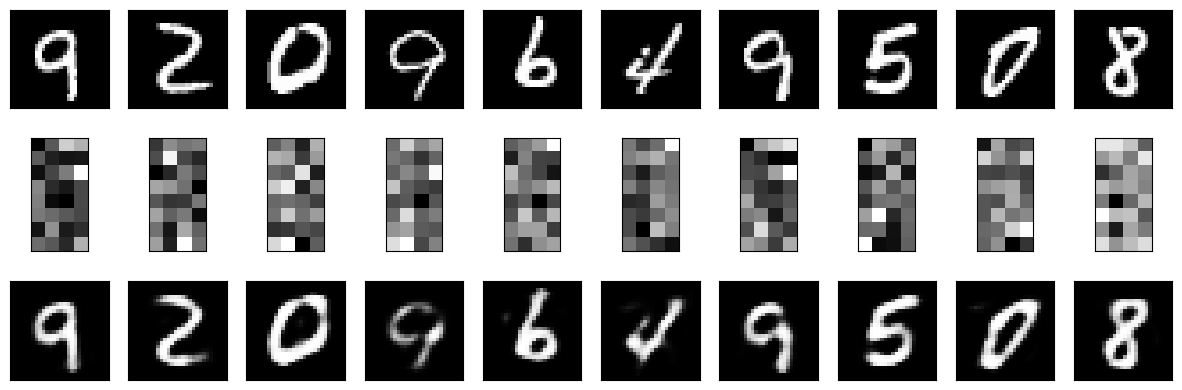

In [36]:
# take 1 batch of the dataset
test_dataset = test_dataset.take(1)

# take the input images and put them in a list
output_samples = []
for input_image, image in tfds.as_numpy(test_dataset):
      output_samples = input_image

# pick 10 random numbers to be used as indices to the list above
idxs = np.random.choice(BATCH_SIZE, size=10)

# get the encoder output
encoded_predicted = encoder_model.predict(test_dataset)

# get a prediction for the test batch
simple_predicted = autoencoder_model.predict(test_dataset)

# display the 10 samples, encodings and decoded values!
display_results(output_samples[idxs], encoded_predicted[idxs], simple_predicted[idxs])

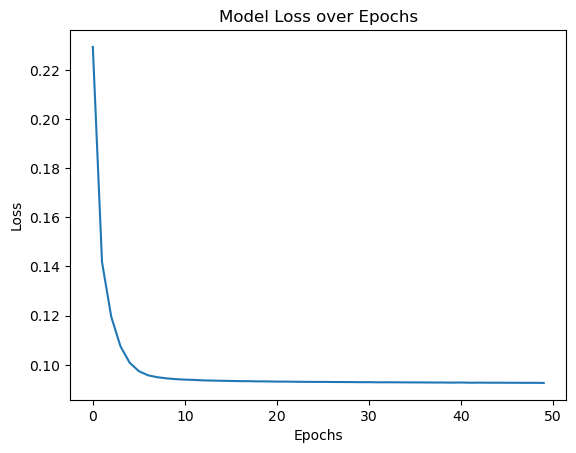

In [38]:
import matplotlib.pyplot as plt

# Plotting the training loss over epochs
plt.plot(simple_auto_history.history['loss'])
plt.title('Model Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

[![Deep.png](https://i.postimg.cc/rp63MntX/Deep.png)](https://postimg.cc/JsqPQQqP)

In [39]:
import tensorflow as tf
from tensorflow.keras ihttps://postimg.cc/JsqPQQqPmport layers, Model

def deep_autoencoder(inputs):
    # --- Encoder ---
    # Layer 1: 128 units, ReLU
    x = layers.Dense(128, activation='relu')(inputs)
    # Layer 2: 64 units, ReLU
    x = layers.Dense(64, activation='relu')(x)
    # Bottleneck: 32 units, ReLU
    bottleneck = layers.Dense(32, activation='relu', name="bottleneck")(x)
    
    # --- Decoder ---
    # Layer 1: 64 units, ReLU
    x = layers.Dense(64, activation='relu')(bottleneck)
    # Layer 2: 128 units, ReLU
    x = layers.Dense(128, activation='relu')(x)
    # Output: 784 units, Sigmoid (to reconstruct pixels between 0 and 1)
    outputs = layers.Dense(784, activation='sigmoid')(x)
    
    return bottleneck, outputs

# Define the Input (Flattened MNIST image)
inputs = layers.Input(shape=(784,), name="input_layer")

# Get outputs from the function
encoder_out, decoder_out = deep_autoencoder(inputs)

# Create the full Autoencoder Model
autoencoder_model = Model(inputs=inputs, outputs=decoder_out, name="Deep_Autoencoder")

# Print the summary
autoencoder_model.summary()

Model: "Deep_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bottleneck (Dense)                   │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 784)                 │         101,136 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
import tensorflow as tf
def simple_autoencoder(inputs):
    encoder=tf.keras.layers.Dense(units=32,activation='relu')(inputs)
    decoder=tf.keras.layers.Dense(units=784,activation='sigmoid')(encoder)
    return encoder,decoder


In [14]:
# def deep_autoencoder():
#     encoder=tf.keras.layers.Dense(units=128,activation='relu')(encoder)
#     encoder=tf.keras.layers.Dense(units=64,activation='relu')(encoder)
#     encoder=tf.keras.layers.Dense(units=32,activation='relu')(encoder)

#     decoder=tf.keras.layers.Dense(units=64,activation='relu')(encoder)
#     decoder=tf.keras.layers.Dense(units=128,activation='relu')(decoder)
#     decoder=tf.keras.layers.Dense(units=784,activation='sigmoid')(decoder)
#     return encoder,decoder
# deep_encoder_output,deep_autoencoder_output=deep_autoencoder()
# deep_encoder_model=tf.keras.Model(inputs=inputs,outputs=deep_encoder_output)
# deep_autoencoder_model=tf.keras.Model(inputs=inputs,outputs=deep_autoencoder_output)

In [13]:
import tensorflow as tf

def deep_autoencoder():
    # Define input
    inputs = tf.keras.layers.Input(shape=(784,))
    
    # Encoder
    encoder = tf.keras.layers.Dense(units=128, activation='relu')(inputs)
    encoder = tf.keras.layers.Dense(units=64, activation='relu')(encoder)
    encoder = tf.keras.layers.Dense(units=32, activation='relu')(encoder)
    
    # Decoder
    decoder = tf.keras.layers.Dense(units=64, activation='relu')(encoder)
    decoder = tf.keras.layers.Dense(units=784, activation='sigmoid')(decoder)
    
    return inputs, encoder, decoder

# Build models
inputs, deep_encoder_output, deep_autoencoder_output = deep_autoencoder()

deep_encoder_model = tf.keras.Model(inputs=inputs, outputs=deep_encoder_output)
deep_autoencoder_model = tf.keras.Model(inputs=inputs, outputs=deep_autoencoder_output)

# Compile the autoencoder
deep_autoencoder_model.compile(optimizer='adam', loss='binary_crossentropy')
